# Analyse des données générée

In [2]:
from importlib import reload

import pandas as pd
import os
import math
from matplotlib import pyplot as plt
import numpy
import random

import networkx as nx

import seaborn as sns

import config
import util
reload(config)
reload(util)
from config import *
from util import *

In [3]:
SAVE_DIR = "data_generated"

df_pollen_synth = pd.read_csv(os.path.join(SAVE_DIR, "df_pollen_synth.csv"))
df_A = pd.read_csv(os.path.join(SAVE_DIR, "df_A.csv"))
df_rk = pd.read_csv(os.path.join(SAVE_DIR, "df_rk.csv"))

In [4]:
df_pollen_synth

,Depth,Picea,Pinus,Alnus,Betula,Quercus,Ambrosia,Chenopodiaceae,Synth_0,Synth_1,...,Synth_90,Synth_91,Synth_92,Synth_93,Synth_94,Synth_95,Synth_96,Synth_97,Synth_98,Synth_99
0,570,16.712329,53.698630,1.917808,8.219178,1.369863,1.369863,1.095890,7.324966,7.389658,...,5.362996,6.025477,2.819414,0.738442,1.746249,1.520317,3.902782,1.087913,5.847397,3.875289
1,580,13.897281,62.235650,0.604230,10.574018,0.604230,1.510574,0.000000,8.168966,7.793240,...,5.982858,5.592813,2.897903,0.750880,1.771247,1.592238,3.766478,1.121393,5.880726,3.794406
2,590,14.005602,59.383753,0.560224,9.523810,1.120448,0.560224,0.280112,10.294703,9.100455,...,7.747282,5.421089,3.188233,0.745596,1.799258,1.623792,3.949575,1.144986,6.353601,3.920251
3,600,12.147887,52.816901,5.545775,13.204225,1.848592,0.000000,0.792254,8.377140,7.701750,...,6.259140,5.659336,2.838290,0.729307,1.752154,1.585008,3.794733,1.149168,5.844652,3.858561
4,610,16.694352,55.315615,0.996678,9.219269,0.996678,0.249169,0.249169,8.269041,8.225230,...,6.487322,5.267811,3.198891,0.716752,1.804741,1.619854,4.027394,1.176068,5.863338,4.092398
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,1140,25.793245,31.320368,0.307062,21.494371,2.456499,1.535312,0.307062,3.941066,4.221249,...,5.133856,4.973965,1.468008,0.864519,1.892490,1.391715,2.386261,0.990628,4.294746,1.960061
58,1150,13.068182,51.704545,0.000000,15.909091,0.852273,0.568182,1.420455,3.238055,3.257034,...,4.032506,4.357792,1.362559,0.869174,1.692918,1.298260,2.049226,0.999637,3.587458,1.671335
59,1160,10.559006,57.142857,0.310559,12.422360,0.931677,3.726708,2.173913,2.726279,2.191609,...,2.889754,2.915985,1.006025,0.956007,1.267216,1.157147,1.514649,1.011659,2.476684,1.309573
60,1170,17.559524,54.166667,0.000000,10.119048,1.190476,1.190476,1.488095,1.951346,1.534780,...,1.854653,1.948873,0.890735,0.987883,1.053135,1.049049,1.239620,1.017578,1.724874,1.113701


In [5]:
df_pollen_synth = df_pollen_synth.sort_values(by="Depth", ascending=False).reset_index(drop=True)

In [6]:
FEATURES_ONLY = [c for c in df_A.columns if not c == "intrinsic" ]
TARGETS_ALL = [c for c in df_pollen_synth.columns if not c in FEATURES_ONLY and not c == "Depth" ]
len(TARGETS_ALL), len(FEATURES_ONLY)

(100, 7)

## Supression de la logistique

$$
\frac{dX_s}{dt}
= r_s\,X_s\left(1 - \frac{X_s}{K_s}\right)
+ X_s \sum_{j} a_{j \to s}\,X_j
$$



$$
x_{i+1} = x_{i} + dx
$$

$$
dx = r_s \times x_i\times( 1 -  \frac{x_i}{k}) + x_i\times A.X_i
$$

$$
y_{i+1} = x_{i+1} - r_s\times x_i\times( 1 -  \frac{x_i}{k})
$$

$$
y_{i+1} = x_{i} + x_i\times A.X_i
$$

In [7]:
r,k = df_rk.to_numpy().T

In [8]:
X = df_pollen_synth[TARGETS_ALL].to_numpy()
Y = X.copy()
Y[1:, :] = X[1:, :] - r*X[:-1, :]*( 1 - X[:-1, :]/k )
#Y[:, :] = X[:, :] - r*X[:, :]*( 1 - X[:, :]/k )

In [9]:
TARGETS_ALL_Y = [t+"_y" for t in TARGETS_ALL]
df_pollen_synth[TARGETS_ALL_Y] = Y

C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\3967285181.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pollen_synth[TARGETS_ALL_Y] = Y
C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\3967285181.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_pollen_synth[TARGETS_ALL_Y] = Y


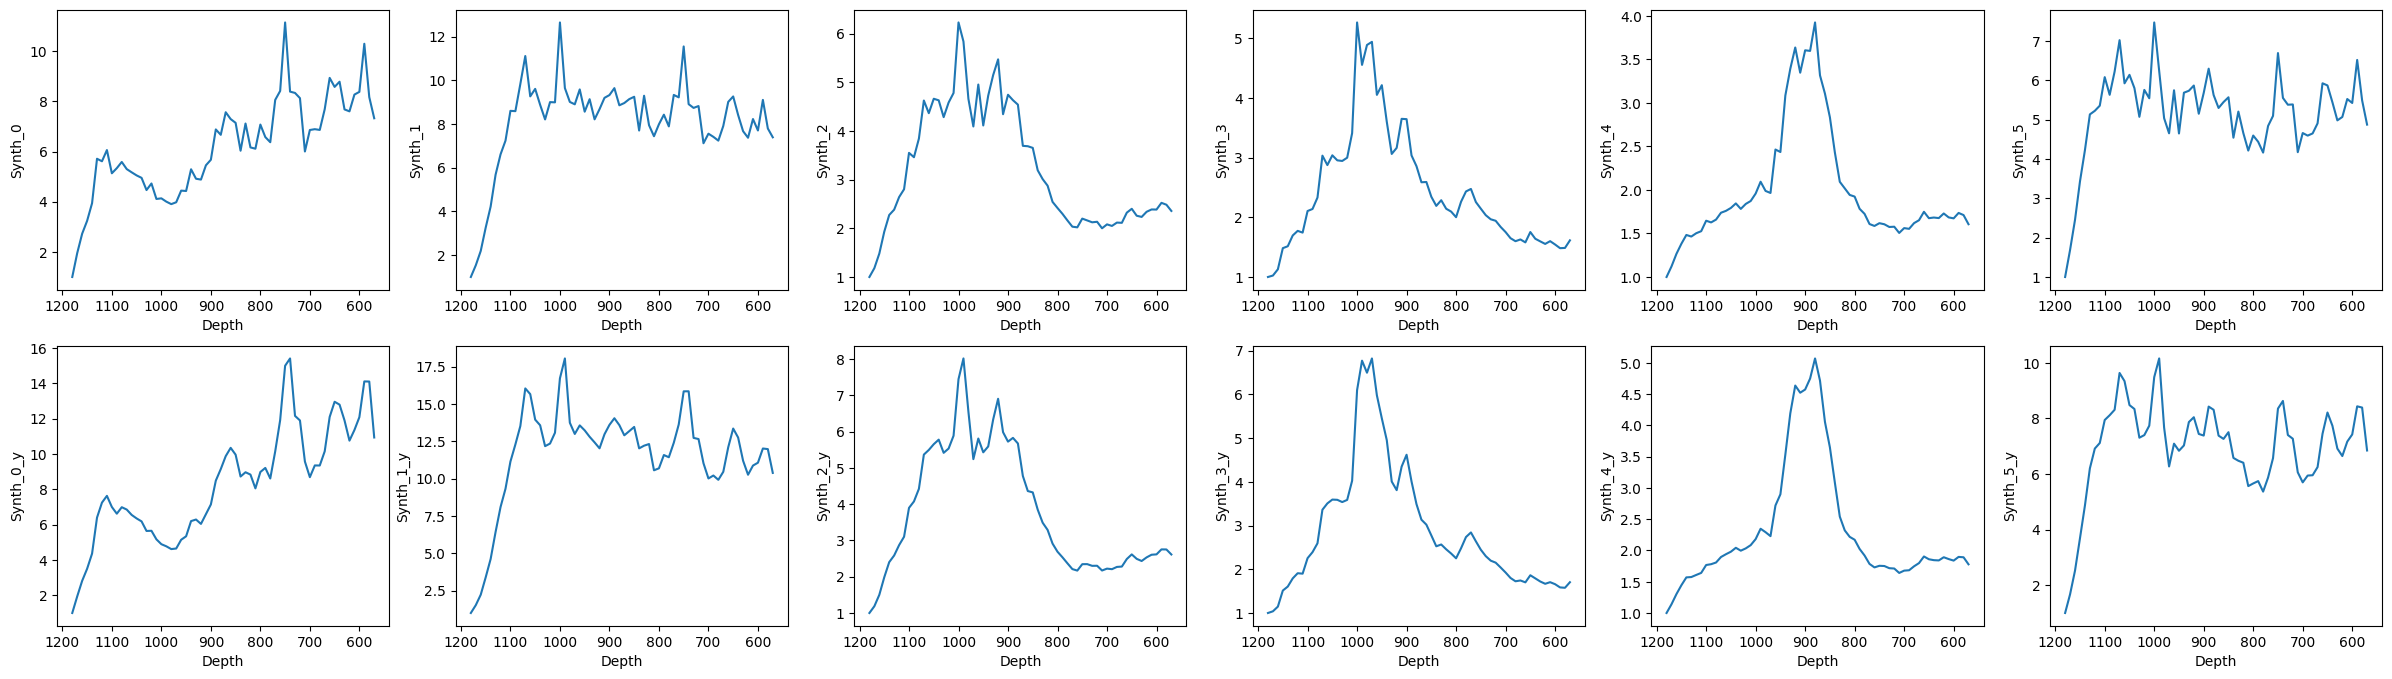

In [10]:
ip = 0


n_rows = 2
n_cols = 6

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

ip = 0
for col in df_pollen_synth.columns:

    if col[:6] == "Synth_" and ip < n_cols:

        ax = axes[0, ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col,
            ax=ax
        )
        
        ax.invert_xaxis()

        
        ax = axes[1, ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col+"_y",
            ax=ax
        )
        
        ax.invert_xaxis()

        ip +=1



In [11]:
df = df_pollen_synth.drop(columns=["Depth"])

## Feature engineering

C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\842157758.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+"_prev"] = df[col].shift(1).iloc[1:]
C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\842157758.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df[col+"_change"] = df[col] - df[col+"_prev"]
C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\842157758.py:9: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider 

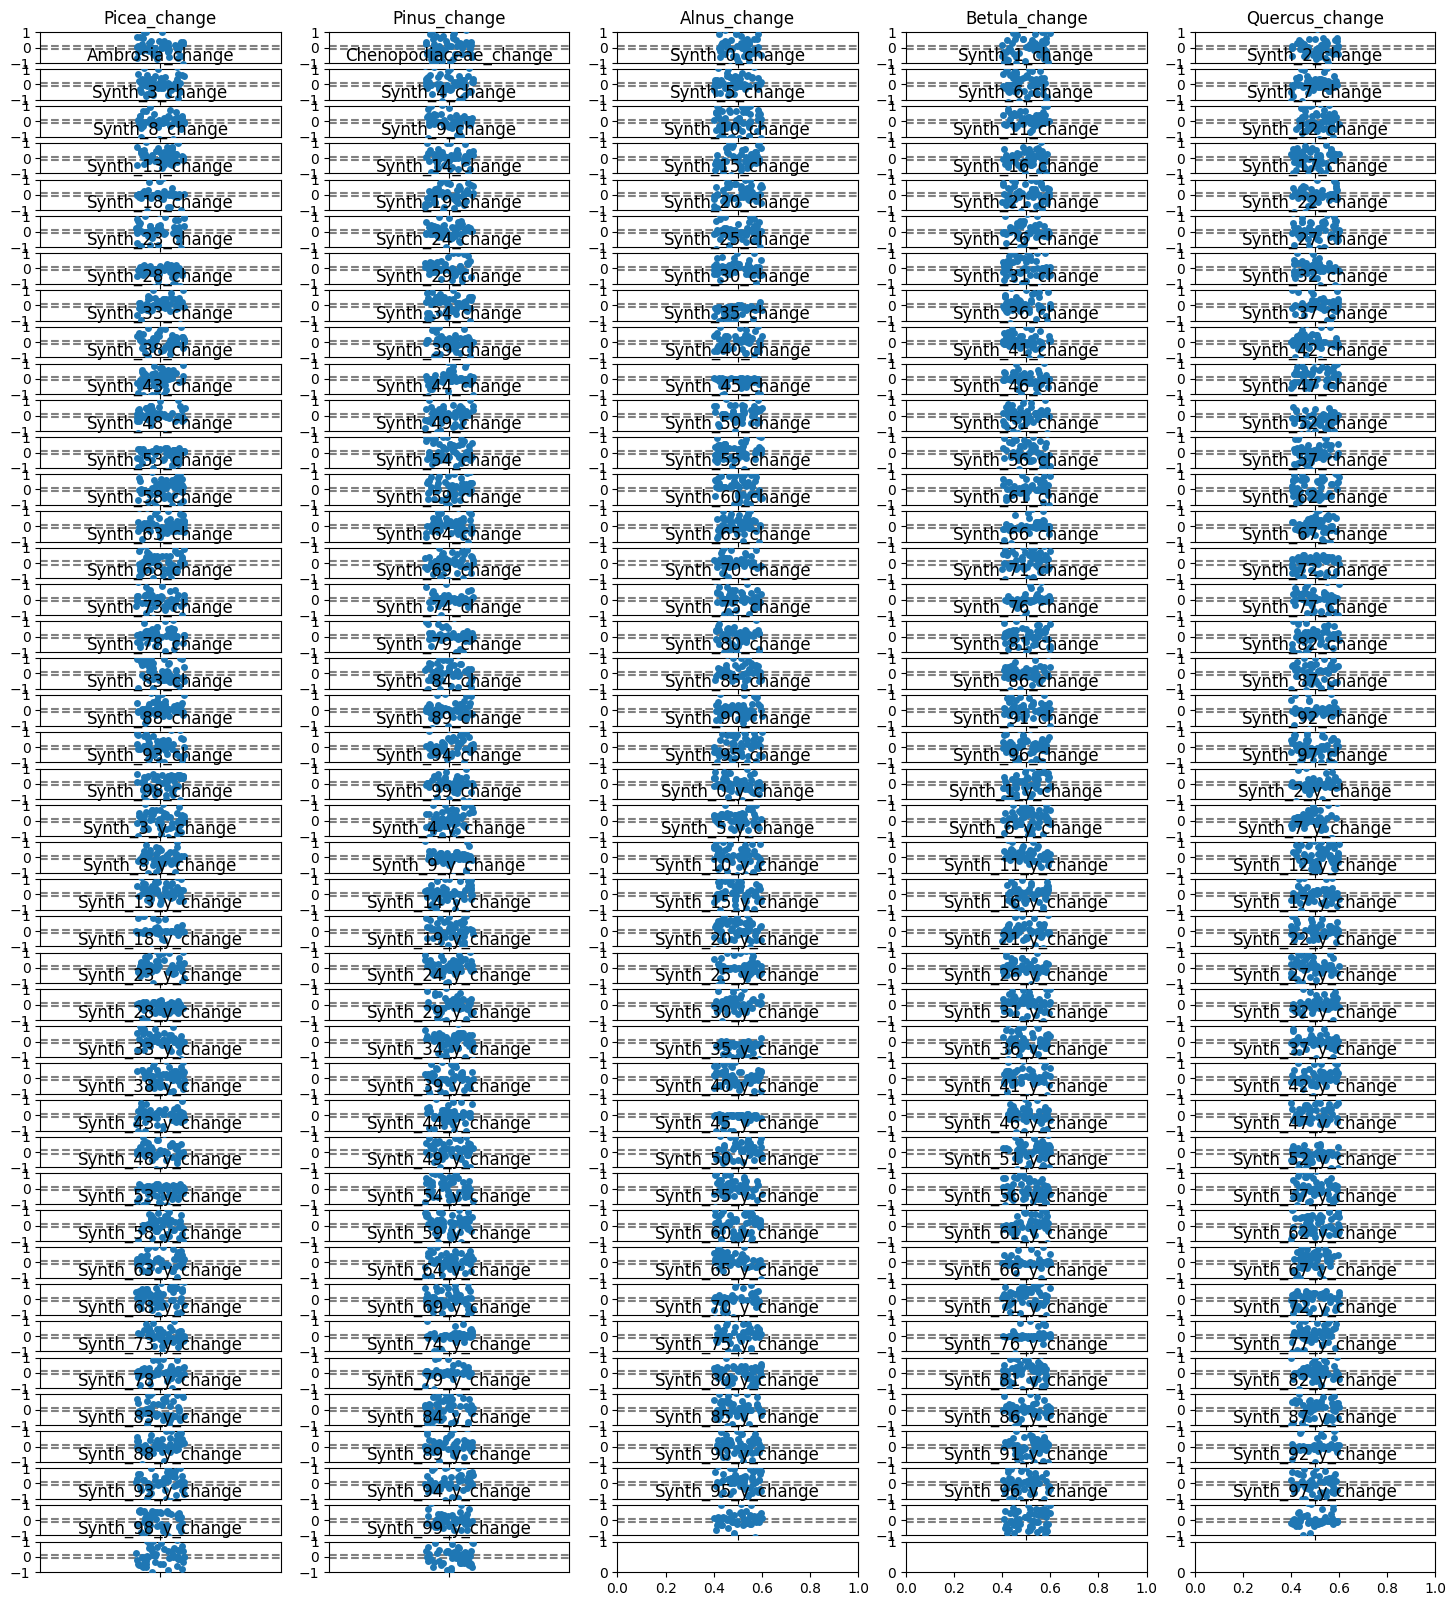

In [12]:
ncols = 5 
nrows = math.ceil(len([col for col in df.columns]) / ncols)

fig, my_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18,20))
fig_id = 0
# Compute change between time step
for col in df.columns:
    # Compute change
    df[col+"_prev"] = df[col].shift(1).iloc[1:]
    df[col+"_change"] = df[col] - df[col+"_prev"]
    #df = df.drop(columns=TARGET)
    df[col+"_change"] = df[col+"_change"] / df[col+"_change"].abs().quantile(0.9)

    ax = my_grid[int(fig_id / ncols)][fig_id % ncols]
    g = sns.stripplot (data=df, y=col+"_change", legend=False, ax=ax)
    ax.set(ylabel="")
    ax.set(ylim=(-1, 1))
    ax.axhline(MIN_UP,color='gray',ls='--')
    ax.axhline(MIN_DOWN,color='gray',ls='--')
    ax.title.set_text(col+"_change")
    df = df.drop(columns=col+"_prev")

    # Discretize change
    df[col+"_change"] = df[col+"_change"].apply(lambda x: -1 if x < MIN_DOWN else 0 if x < MIN_UP else 1)

    fig_id += 1


,Picea,Pinus,Alnus,Betula,Quercus,Ambrosia,Chenopodiaceae,Synth_0,Synth_1,Synth_2,...,Synth_90_y_change,Synth_91_y_change,Synth_92_y_change,Synth_93_y_change,Synth_94_y_change,Synth_95_y_change,Synth_96_y_change,Synth_97_y_change,Synth_98_y_change,Synth_99_y_change
0,2,0,0,0,1,0,0,0,0,0,...,1,1,1,1,1,1,1,1,1,1
1,2,1,0,0,0,1,2,0,0,0,...,1,1,-1,-1,0,1,1,0,1,1
2,2,2,0,0,0,2,2,0,0,0,...,1,1,1,-1,1,1,1,0,1,1
3,2,0,0,2,0,0,2,0,0,0,...,1,1,1,-1,1,1,1,0,1,1
4,2,0,0,2,1,1,0,0,0,0,...,1,1,1,-1,1,1,1,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
57,2,1,0,0,0,0,0,2,1,1,...,1,1,1,1,0,0,1,-1,1,0
58,2,0,2,1,1,0,1,2,0,1,...,1,1,-1,1,0,-1,-1,-1,1,-1
59,2,2,0,0,0,0,0,2,2,1,...,1,0,1,1,0,0,0,0,1,0
60,2,2,0,0,0,1,0,2,0,1,...,1,0,-1,1,0,0,-1,-1,0,-1


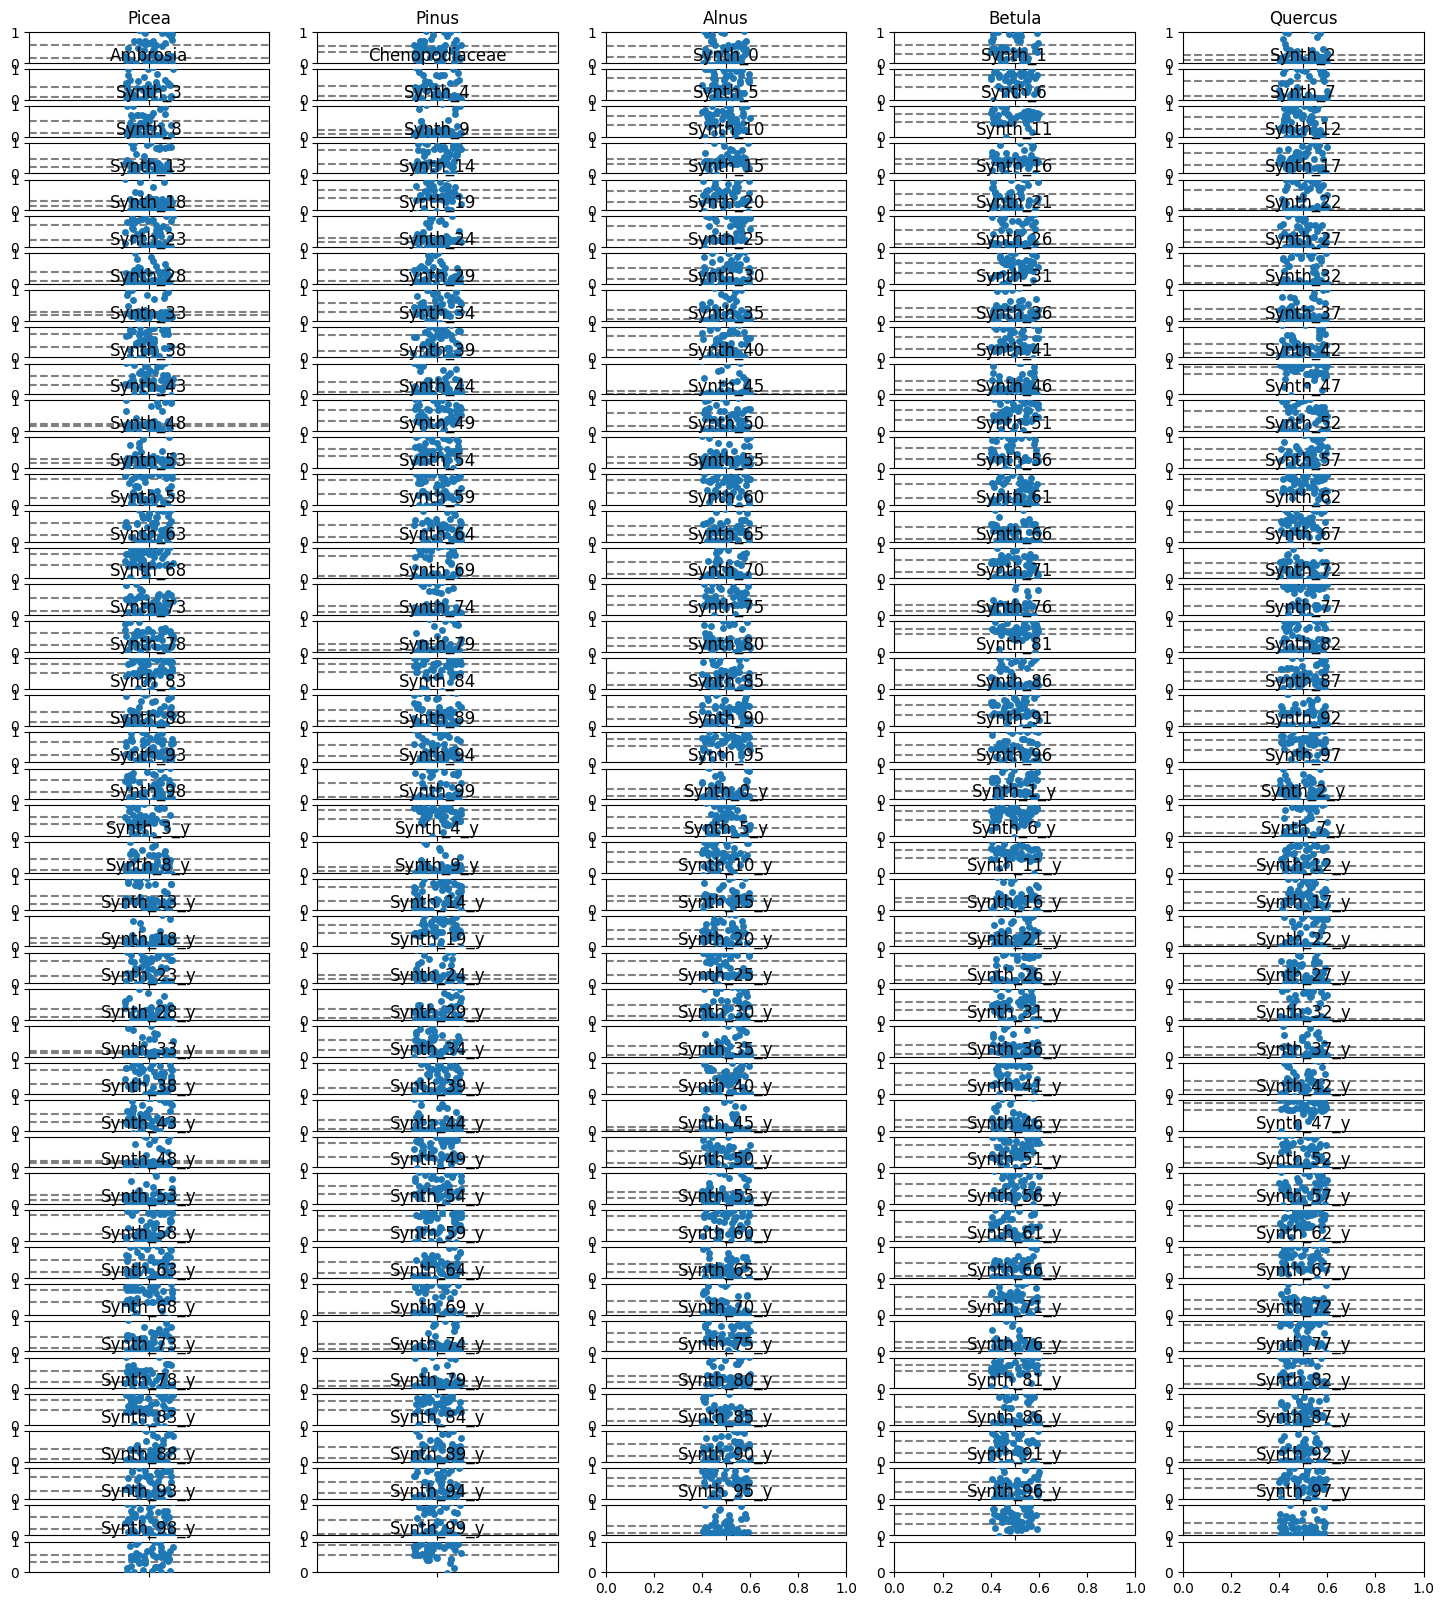

In [13]:
ncols = 5 
nrows = math.ceil(len([col for col in df.columns if "_change" not in col]) / ncols)

fig, my_grid = plt.subplots(nrows=nrows, ncols=ncols, figsize=(18,20))
fig_id = 0

# Discretize value
for col in [col for col in df.columns if "change" not in col]:
    df[col] = (df[col]-df[col].quantile(0.1)) / (df[col].quantile(0.9)-df[col].quantile(0.1))

    ax = my_grid[int(fig_id / ncols)][fig_id % ncols]
    g = sns.stripplot (data=df, y=col, legend=False, ax=ax)
    ax.set(ylabel="")
    ax.set(ylim=(0, 1))
    ax.axhline(df[col].quantile(0.66),color='gray',ls='--')
    ax.axhline(df[col].quantile(0.33),color='gray',ls='--')
    ax.title.set_text(col)
    
    df[col] = df[col].apply(lambda x: 0 if x < df[col].quantile(0.33) else 1 if x < df[col].quantile(0.66) else 2)

    fig_id += 1


# Compute change of charcoal
#df["charcoal_change"] = df[CHARCOAL_ID].shift()
#df["charcoal_change"] = df["charcoal_change"] - df[CHARCOAL_ID]

#df = df[(df["charcoal_change"] > -1) & (df["charcoal_change"] < 1)]
#sns.catplot(data=df, y="charcoal_change")

#df["charcoal_change"] = df["charcoal_change"].apply(lambda x: "up" if x > 0 else "down")
#df["charcoal_change"] = df["charcoal_change"].apply(lambda x: x > 0)
#df = df.drop(axis=1, columns=CHARCOAL_ID)
df = df.dropna()

display(df)

df.to_csv(DISCRETE_DATA_PATH, index=False)

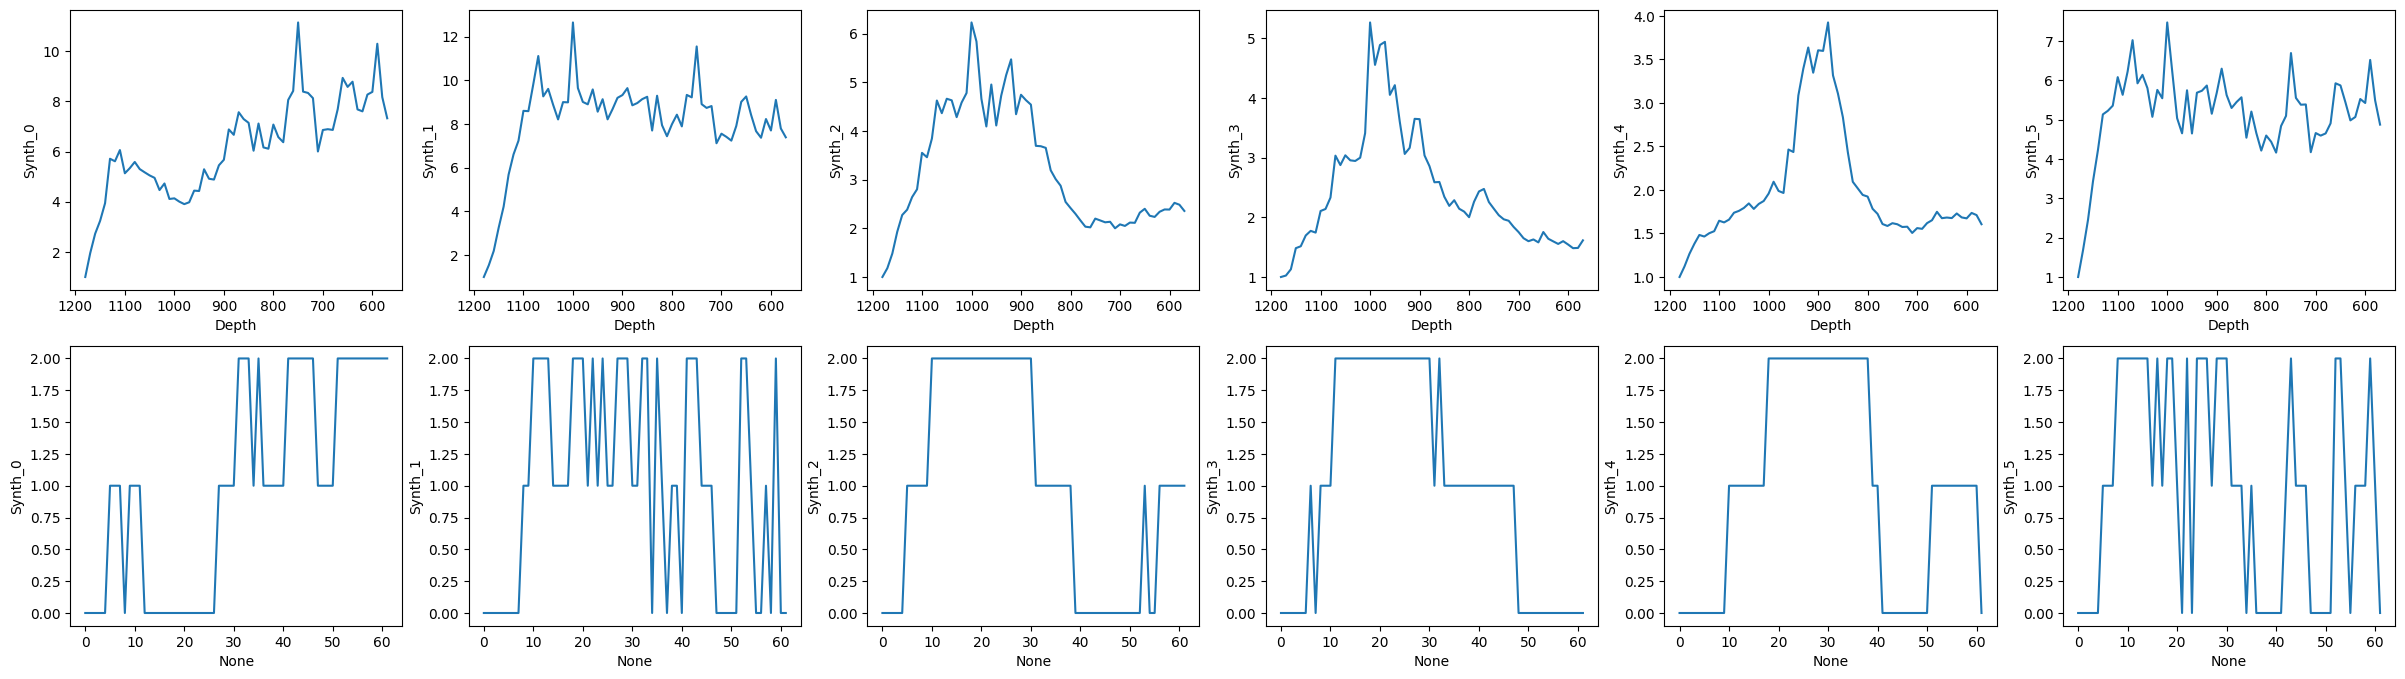

In [14]:
ip = 0

n_rows = 2
n_cols = 6

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharex=False,
    sharey=False
)

ip = 0
for col in df_pollen_synth.columns:

    if col[:6] == "Synth_" and ip < n_cols:

        ax = axes[0,ip]
        sns.lineplot(
            data=df_pollen_synth,
            x="Depth",
            y=col,
            ax=ax
        )
        
        ax.invert_xaxis()

        ax = axes[1,ip]
        sns.lineplot(
            data=df,
            x=df.index,
            y=col,
            ax=ax
        )
    

        ip +=1

## LFIT

In [15]:
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
numpy.random.seed(RANDOM_SEED)

In [16]:
TARGETS_ALL[:1]

['Synth_0']

In [17]:
TARGETS = TARGETS_ALL[:1]
FEATURES = FEATURES_ONLY + TARGETS
len(TARGETS), len(FEATURES)

(1, 8)

In [18]:
l_infuences = analyse(FEATURES_ONLY, TARGETS_ALL + TARGETS_ALL_Y, DISCRETE_DATA_PATH)

Starting fit with GULA

Converting transitions to nparray...
Sorting transitions...
Grouping transitions by initial state...
Start learning over 32 threads
c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:137: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_output = pd.concat([df_output,df_tmp])
Starting fit with GULA

Converting transitions to nparray...
Sorting transitions...
Grouping transitions by initial state...
Start learning over 32 threads
c:\Users\mehls\Documents\ECN\Projet Forêt Boréal\github\boreal-forest\util.py:137: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determi

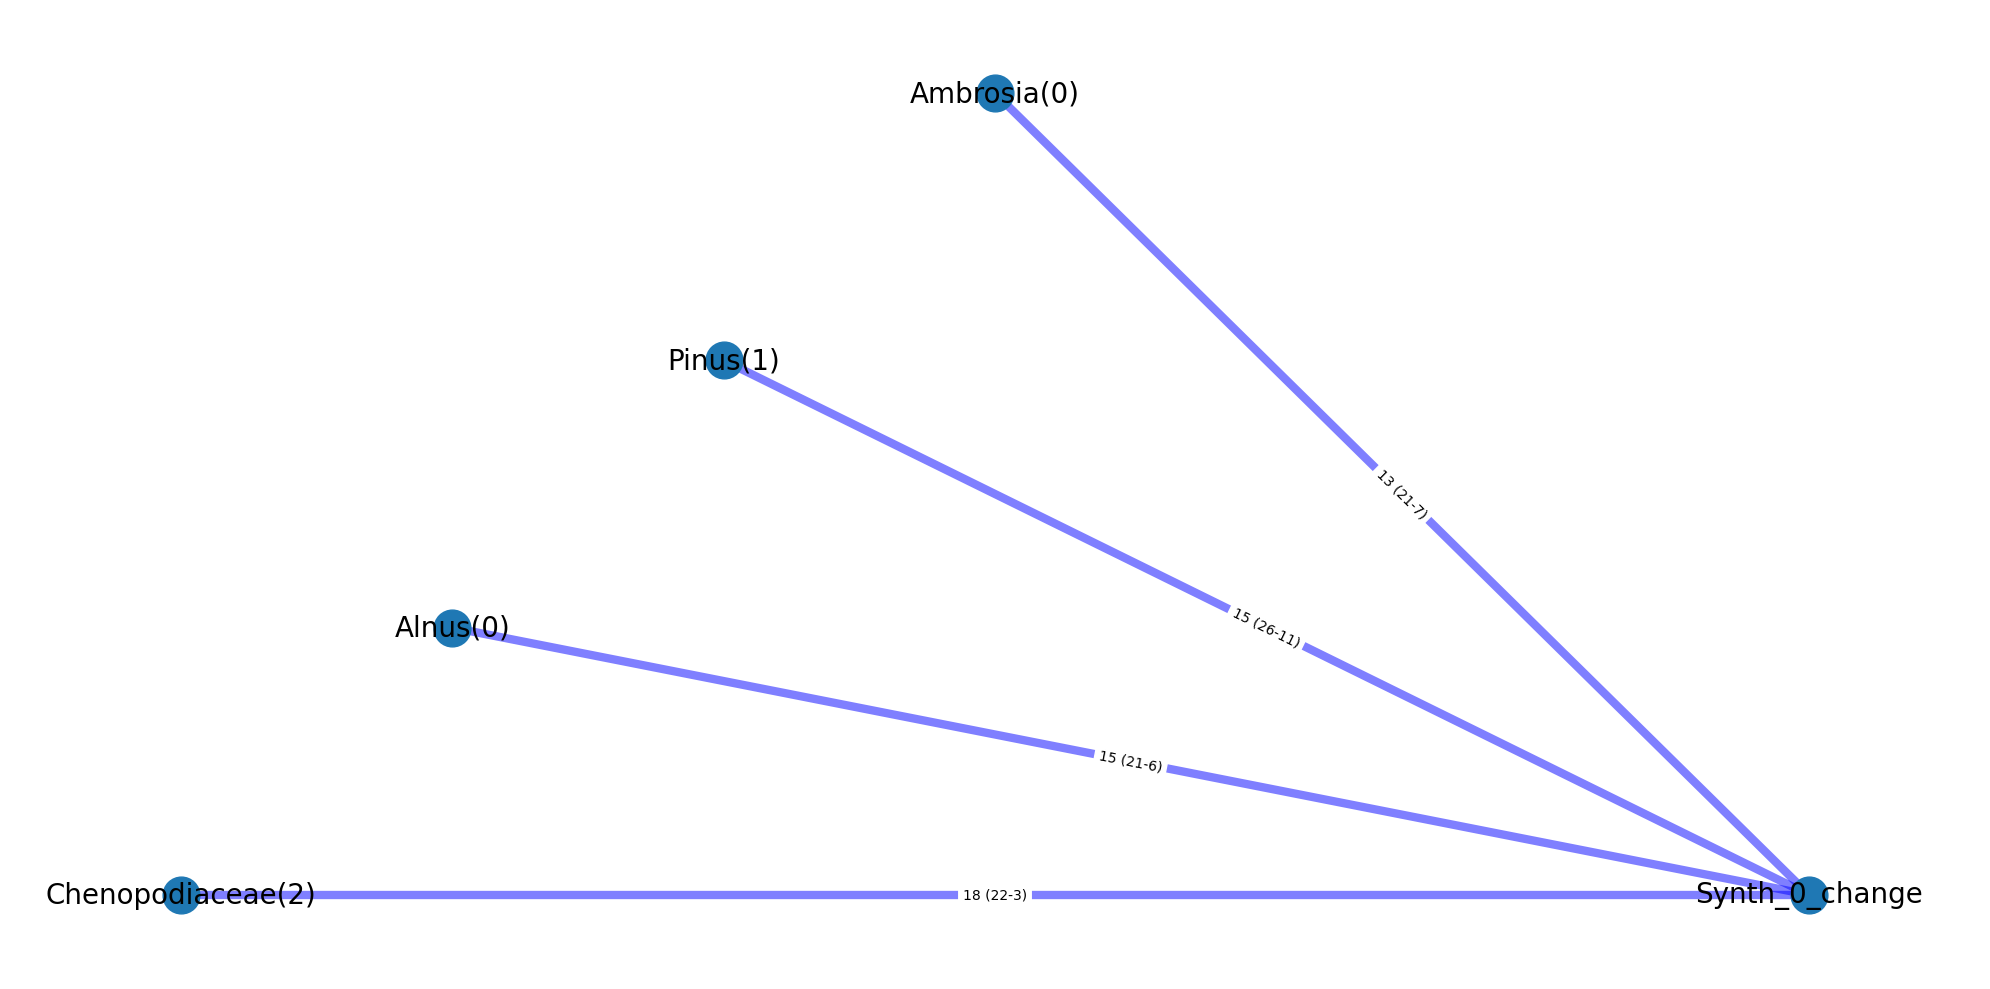

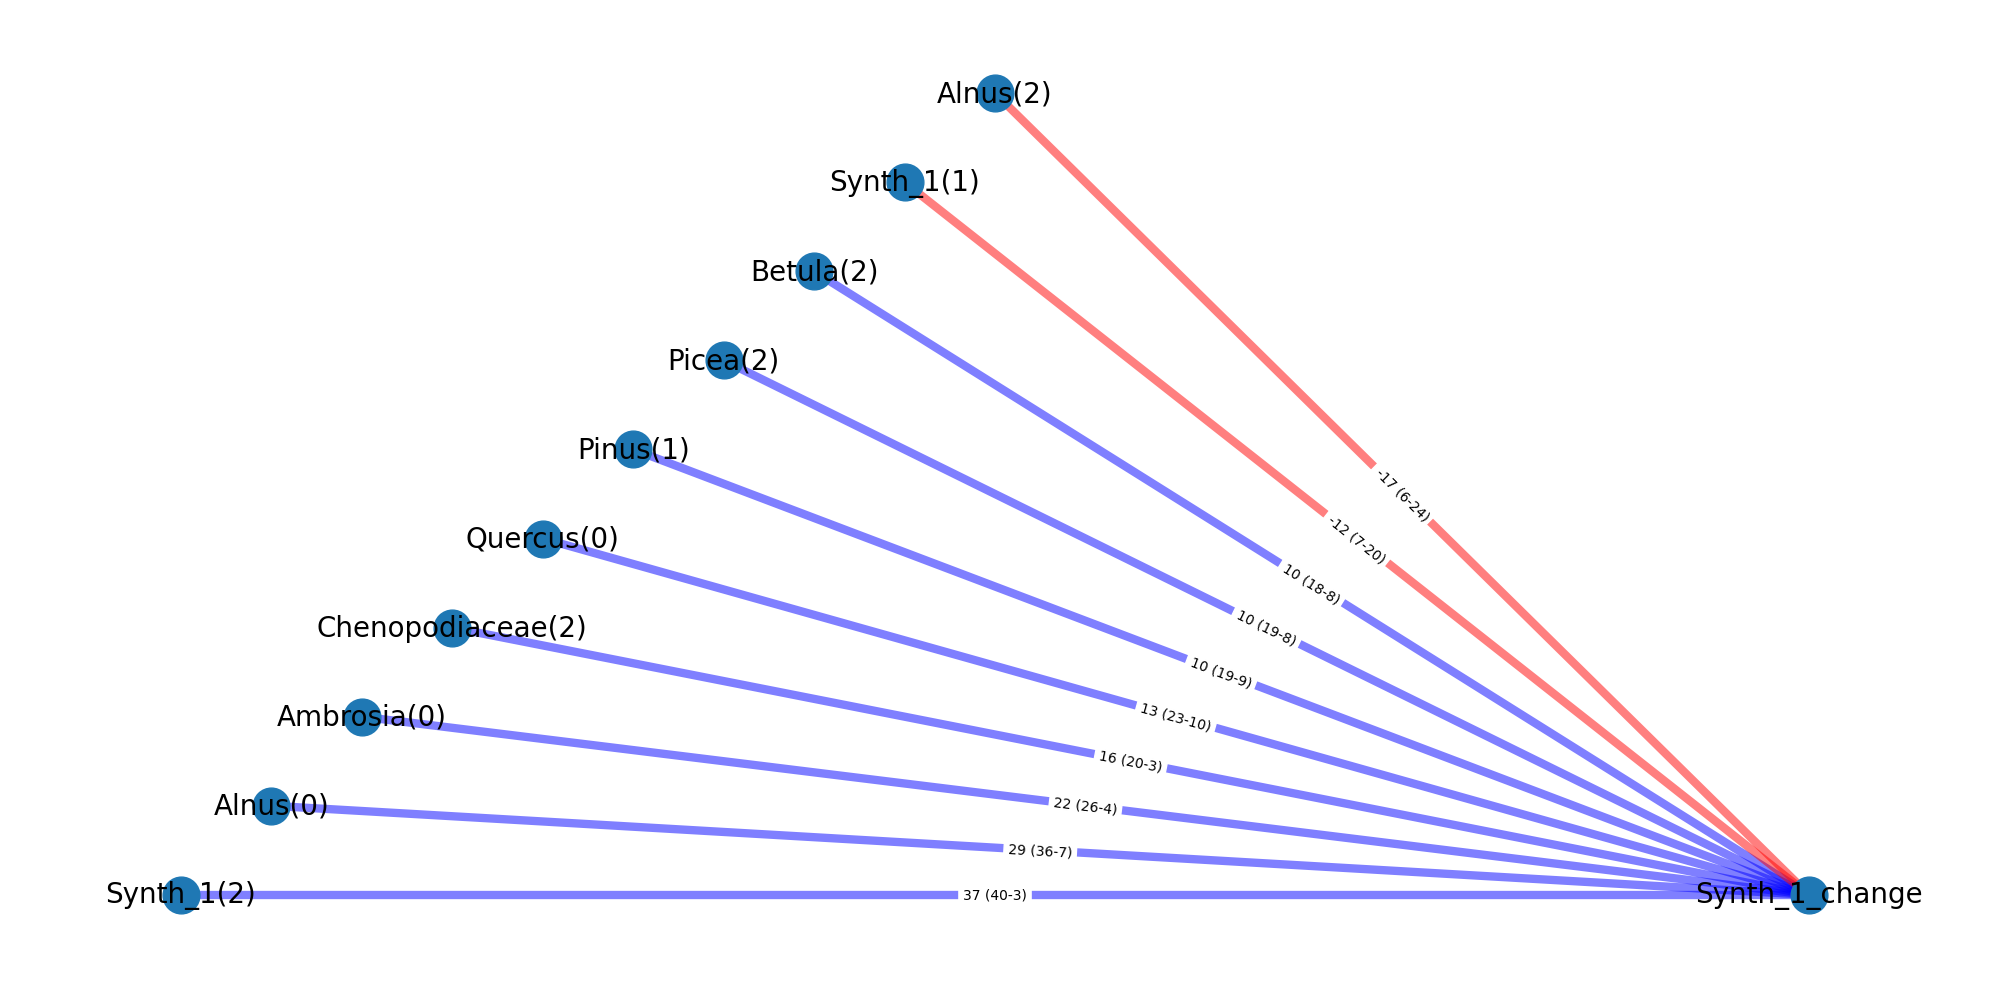

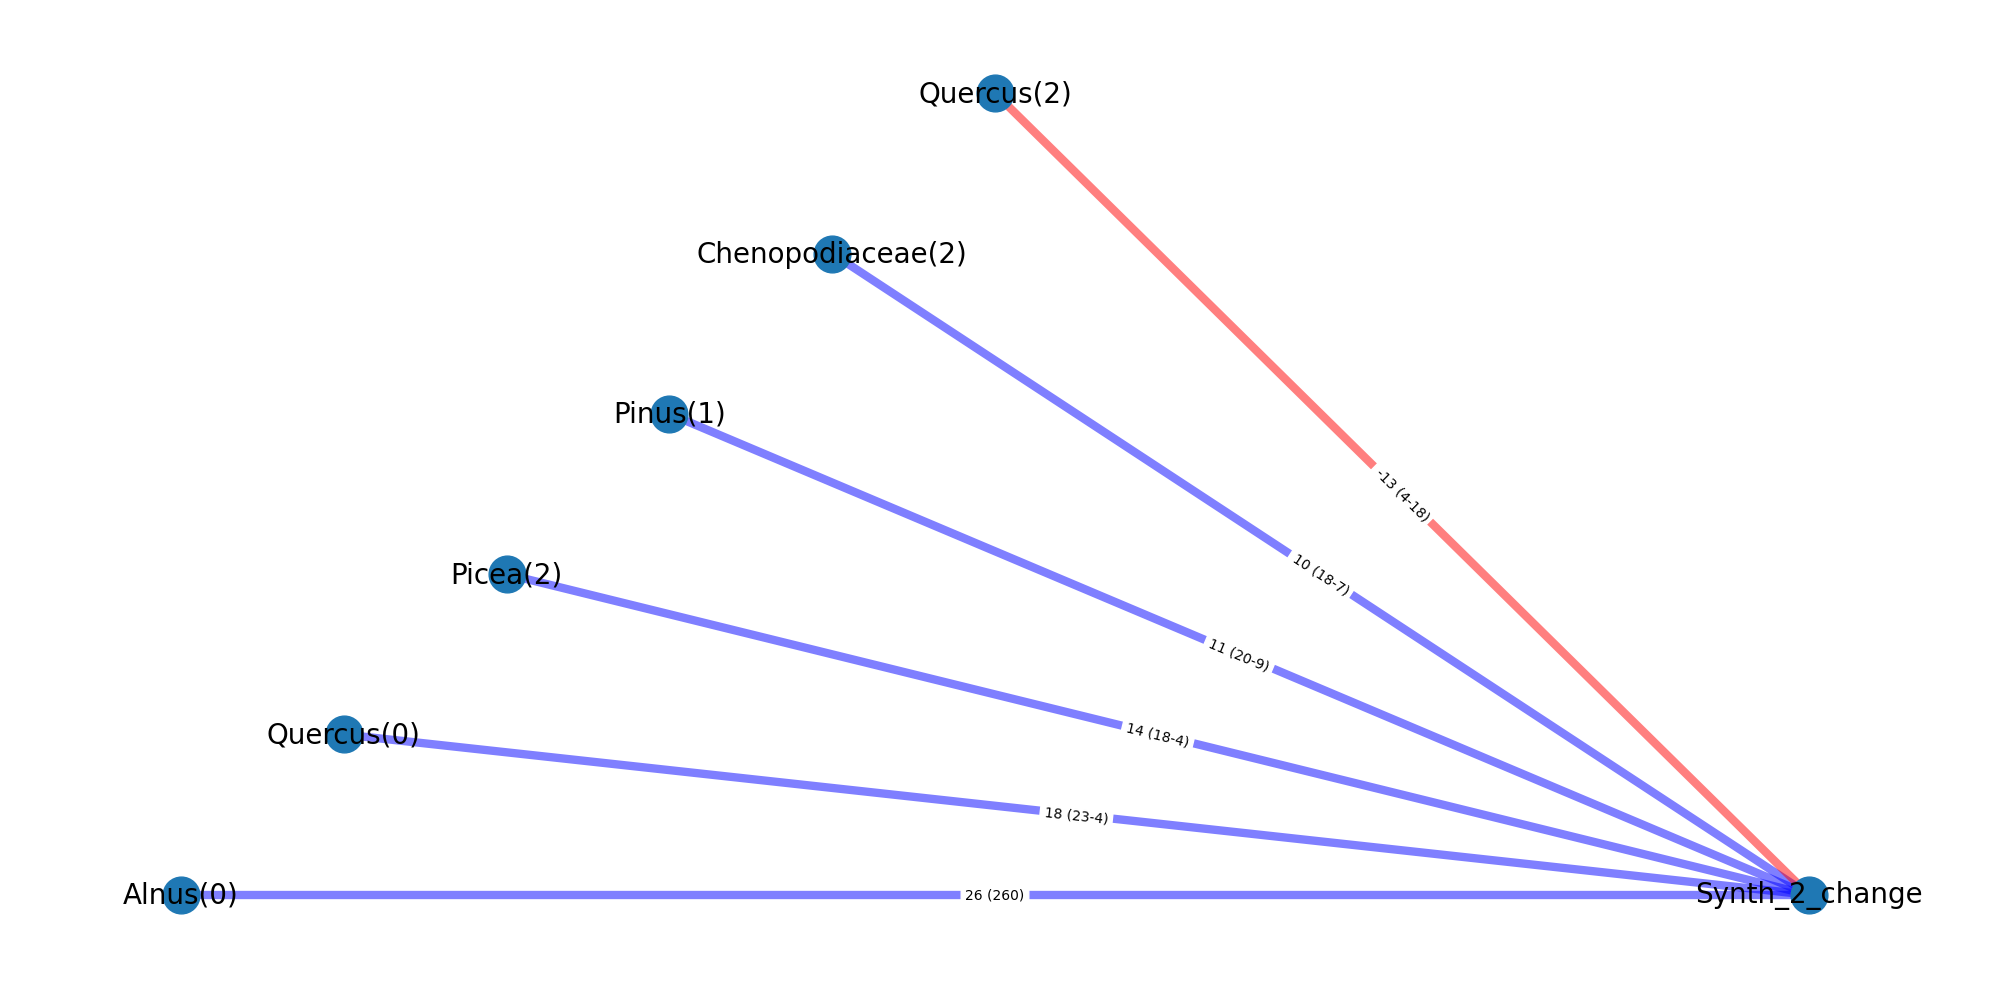

In [19]:
for i_f in range(min(len(l_infuences), 3)):
    df_influences = l_infuences[i_f]
            
    for target in df_influences["target"].unique():
        fig, ax = plt.subplots(figsize=(20,10))
        G = nx.Graph()

        MIN_INFLUENCE_SUPPORT = 10

        df_tmp = df_influences[(df_influences["target"] == target) &
                            (df_influences["feature"] != target) &
                            (
                                (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                            )]

        #display(df_tmp)
        for idx, row in df_tmp.iterrows():
            G.add_edge(row["feature"], row["target"], weight=row["influence"], label=str(row["influence"])+" ("+str(int(row["positive_influence"]))+str(int(-row["negative_influence"]))+")")

        positive_edge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] >= MIN_INFLUENCE_SUPPORT]
        negative_edge = [(u, v) for (u, v, d) in G.edges(data=True) if d["weight"] <= -MIN_INFLUENCE_SUPPORT]

        pos = nx.planar_layout(G)  # positions for all nodes - seed for reproducibility

        # nodes
        nx.draw_networkx_nodes(G, pos, node_size=700, ax=ax)

        # edges
        nx.draw_networkx_edges(G, pos, edgelist=positive_edge, width=6, alpha=0.5, edge_color="b", ax=ax)
        nx.draw_networkx_edges(G, pos, edgelist=negative_edge, width=6, alpha=0.5, edge_color="r", ax=ax)

        # node labels
        nx.draw_networkx_labels(G, pos, font_size=20, font_family="sans-serif", ax=ax)
        # edge weight labels
        edge_labels = nx.get_edge_attributes(G, "label")
        nx.draw_networkx_edge_labels(G, pos, edge_labels, ax=ax)

        plt.axis("off")
        plt.tight_layout()
        plt.show()

# Résultats

## Heuristique 1

Utilisation du niveau 2 pour conclure : 

- si inf_2 > MIN_INF : influence
- sinon : pas d'influence totale

## Heuristique 2

Utilisation des niveaux 0 et 2 pour conclure : 

- si 0 et 2 influent et de même signe : incohérent
- si au moins un deux influent et les deux de signes diférents : influence totale : sign( sign(inf_2) - sign(inf_0) ) 
- sinon : ni 0 et 2 influent : pas d'influence totale

In [20]:
MIN_INFLUENCE_SUPPORT = 10

In [21]:

def heuristique_1(l_infuences, MIN_INFLUENCE_SUPPORT = 10):
    influences_totale_1 = []

    for i_f in range(len(l_infuences)):
        df_influences = l_infuences[i_f]
            
        # extraction avec regex
        df_influences[["feature_name", "feature_level"]] = df_influences["feature"].str.extract(r"(.+)\((\d+)\)")

        # si tu veux feature_level en int
        df_influences["feature_level"] = df_influences["feature_level"].astype(int)

        df_influences["influence_with_level"] = df_influences["influence"]*(df_influences["feature_level"]-1)
        df_influences["sign_influence_with_level"] = np.sign(df_influences["influence_with_level"])*(
                                    (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                    (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                                )

        taget_influence = dict()

        for target in df_influences["target"].unique():

            df_tmp = df_influences[(df_influences["target"] == target) &
                                (df_influences["feature"] != target) &
                                (
                                    (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                    (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                                )]
            
            # 1) ne garder que level 2
            sub = df_tmp[df_tmp["feature_level"] == 2].copy()

            sub["sign"] = np.sign(sub["influence"])
            influence_names = sub["feature_name"].values

            taget_influence[target] = {name: (int(sub.loc[sub["feature_name"]==name,"sign"].values[0]) if name in influence_names 
                                            else 0)
                                    for name in df_influences["feature_name"].unique() }

        influences_totale_1.append(taget_influence)
    return influences_totale_1


def heuristique_2(l_infuences, MIN_INFLUENCE_SUPPORT = 10):

    influences_totale_2 = []

    for i_f in range(len(l_infuences)):
        df_influences = l_infuences[i_f]
            
        # extraction avec regex
        df_influences[["feature_name", "feature_level"]] = df_influences["feature"].str.extract(r"(.+)\((\d+)\)")

        # si tu veux feature_level en int
        df_influences["feature_level"] = df_influences["feature_level"].astype(int)

        df_influences["influence_with_level"] = df_influences["influence"]*(df_influences["feature_level"]-1)
        df_influences["sign_influence_with_level"] = np.sign(df_influences["influence_with_level"])*(
                                    (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                    (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                                )

        target_incoherence = dict()
        taget_influence = dict()

        for target in df_influences["target"].unique():

            df_tmp = df_influences[(df_influences["target"] == target) &
                                (df_influences["feature"] != target) &
                                (
                                    (df_influences["influence"] >= MIN_INFLUENCE_SUPPORT) |
                                    (df_influences["influence"] <= -MIN_INFLUENCE_SUPPORT)
                                )]
            
            # 1) ne garder que levels 0 et 2
            sub = df_tmp[df_tmp["feature_level"].isin([0, 2])].copy()

            # 2) signe de l'influence (-1, +1)
            sub["sign"] = np.sign(sub["influence"])

            # 3) pour chaque feature_name : incohérent si on a 0 ET 2 et que les signes sont identiques (et non nuls)
            g = sub.groupby("feature_name")

            has0 = g["feature_level"].apply(lambda s: (s == 0).any())
            has2 = g["feature_level"].apply(lambda s: (s == 2).any())

            sign0 = g.apply(lambda x: x.loc[x["feature_level"] == 0, "sign"].iloc[0] if (x["feature_level"] == 0).any() else np.nan)
            sign2 = g.apply(lambda x: x.loc[x["feature_level"] == 2, "sign"].iloc[0] if (x["feature_level"] == 2).any() else np.nan)
            
            has0not0 = has0 & (sign0 != 0)
            has2not0 = has2 & (sign2 != 0)

            has0n0and2n0 = has0not0 & has2not0
            # incohérent si : level 0 et 2 de même signe
            mask_inco = has0not0 & has2not0 & (sign0 == sign2)
            incoherent_names = mask_inco[mask_inco].index

            # conclusif influent si : on a au moins 0 non nul ou 2 non nul ET si les deux ALORS de signes différents

            mask_influ = (has0not0 | has2not0) & ( ~has0n0and2n0 | (sign0 !=sign2) )
            influence_names = mask_influ[mask_influ].index

            target_incoherence[target] = incoherent_names

            taget_influence[target] = {name : None if name in incoherent_names else 
                                    (int(np.sign(sum(df_influences[df_influences["feature_name"]==name ]["sign_influence_with_level"].values))) if name in influence_names else 0)
                                    for name in df_influences["feature_name"].unique() }

        influences_totale_2.append(taget_influence)

    return influences_totale_2



In [ ]:
def table_stat(influences_totale, incoherent=True):

    cpt = {"incoherent_nul" : 0, "incoherent_neg" : 0, "incoherent_pos" : 0, 
        "nul_nul" : 0, "nul_neg" : 0, "nul_pos" : 0,
        "neg_nul" : 0, "neg_neg" : 0, "neg_pos" : 0,
        "pos_nul" : 0, "pos_neg" : 0, "pos_pos" : 0 }

    for i in range(len(influences_totale)):
        inf_True = df_A.loc[i]

        for d_feat in influences_totale[i].values():
            for feat_name, res in d_feat.items():
                if feat_name in inf_True.index:
                    inf_t = inf_True[feat_name]

                    if res is None and incoherent:
                        if inf_t == 0:
                            cpt["incoherent_nul"]+=1
                        elif inf_t < 0:
                            cpt["incoherent_neg"]+=1
                        else:
                            cpt["incoherent_pos"]+=1

                    elif res == 0:
                        if inf_t == 0:
                            cpt["nul_nul"]+=1
                        elif inf_t < 0:
                            cpt["nul_neg"]+=1
                        else:
                            cpt["nul_pos"]+=1

                    elif res < 0:
                        if inf_t == 0:
                            cpt["neg_nul"]+=1
                        elif inf_t < 0:
                            cpt["neg_neg"]+=1
                        else:
                            cpt["neg_pos"]+=1
                    else:
                        if inf_t == 0:
                            cpt["pos_nul"]+=1
                        elif inf_t < 0:
                            cpt["pos_neg"]+=1
                        else:
                            cpt["pos_pos"]+=1


    pd_stat = pd.DataFrame( [ [cpt["incoherent_nul"], cpt["nul_nul"], cpt["neg_nul"], cpt["pos_nul"]],
                                [cpt["incoherent_neg"], cpt["nul_neg"], cpt["neg_neg"], cpt["pos_neg"]],
                                [cpt["incoherent_pos"], cpt["nul_pos"], cpt["neg_pos"], cpt["pos_pos"]]], 
                        columns=["incoherent", "not_influent", "influence neg", "influence pos"], index=["A nul","A neg", "A pos" ])


    # somme par colonne (uniquement numériques)
    sum_row = pd_stat.select_dtypes("number").sum()

    # ajouter la ligne à la fin
    pd_stat.loc["SUM"] = sum_row
    pd_stat["SUM"] = pd_stat.select_dtypes("number").sum(axis=1)

    pd_red = pd_stat.loc[["A nul", "A neg", "A pos"], ["not_influent","influence neg","influence pos"]]

    

    return pd_stat


### Resultats

In [23]:
l_infuences_x = [inf for inf in l_infuences if not "_y" in inf.target[0]]
l_infuences_y = [inf for inf in l_infuences if "_y" in inf.target[0]]

In [24]:
x_h1 = heuristique_1(l_infuences_x)
x_h2 = heuristique_2(l_infuences_x)
y_h1 = heuristique_1(l_infuences_y)
y_h2 = heuristique_2(l_infuences_y)

C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\2218588302.py:87: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sign0 = g.apply(lambda x: x.loc[x["feature_level"] == 0, "sign"].iloc[0] if (x["feature_level"] == 0).any() else np.nan)
C:\Users\mehls\AppData\Local\Temp\ipykernel_3560\2218588302.py:88: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sign2 = g.apply(lambda x: x.loc[x["feature_level"] == 2, "sign"

In [25]:
pd_stat_x_h1 = table_stat(x_h1)
pd_stat_x_h2 = table_stat(x_h2)
pd_stat_y_h1 = table_stat(y_h1)
pd_stat_y_h2 = table_stat(y_h2)

In [57]:
def precision(pd_stat):
    pd_red = pd_stat.loc[["A nul", "A neg", "A pos"], ["not_influent","influence neg","influence pos"]]
    accuracy = np.trace(pd_red.values) / pd_red.values.sum()
    return accuracy

def sensibilite(pd_stat):
    pd_red = pd_stat.loc[["A nul", "A neg", "A pos"], ["not_influent","influence neg","influence pos"]]
    recall = pd_red.div(pd_red.sum(axis=1), axis=0)
    return np.diag(recall)
    
def fiabilite(pd_stat):
    pd_red = pd_stat.loc[["A nul", "A neg", "A pos"], ["not_influent","influence neg","influence pos"]]
    precision = pd_red.div(pd_red.sum(axis=0), axis=1)
    return np.diag(precision )

In [60]:
pd_stat_x_h1

,incoherent,not_influent,influence neg,influence pos,SUM
A nul,0,200,76,65,341
A neg,0,44,17,10,71
A pos,0,146,44,98,288
SUM,0,390,137,173,700


In [81]:
pd_stat_x_h1[ ["not_influent","influence neg","influence pos", "SUM"]]

,not_influent,influence neg,influence pos,SUM
A nul,200,76,65,341
A neg,44,17,10,71
A pos,146,44,98,288
SUM,390,137,173,700


In [82]:
pd_stat_y_h1[ ["not_influent","influence neg","influence pos", "SUM"]]

,not_influent,influence neg,influence pos,SUM
A nul,170,90,81,341
A neg,36,22,13,71
A pos,115,33,140,288
SUM,321,145,234,700


In [83]:
140/234

0.5982905982905983

In [62]:
precision(pd_stat_x_h1), sensibilite(pd_stat_x_h1), fiabilite(pd_stat_x_h1)

(np.float64(0.45),
 array([0.58651026, 0.23943662, 0.34027778]),
 array([0.51282051, 0.12408759, 0.56647399]))

In [63]:
precision(pd_stat_y_h1), sensibilite(pd_stat_y_h1), fiabilite(pd_stat_y_h1)

(np.float64(0.4742857142857143),
 array([0.49853372, 0.30985915, 0.48611111]),
 array([0.52959502, 0.15172414, 0.5982906 ]))

In [28]:
pd_stat_x_h2

,incoherent,not_influent,influence neg,influence pos,SUM
A nul,16,117,140,68,341
A neg,4,26,31,10,71
A pos,4,113,72,99,288
SUM,24,256,243,177,700


In [30]:
pd_stat_y_h2

,incoherent,not_influent,influence neg,influence pos,SUM
A nul,26,86,149,80,341
A neg,4,18,37,12,71
A pos,18,67,79,124,288
SUM,48,171,265,216,700


## Variation du seuil

In [76]:
MIN_INFLUENCE_SUPPORT_V = np.arange(1, 30)

x_h1_v = [heuristique_1(l_infuences_x, min_support) for min_support in MIN_INFLUENCE_SUPPORT_V]
pd_stat_x_h1_v = [table_stat(h1) for h1 in  x_h1_v]
prec_x_v = [precision(pd_stat) for pd_stat in pd_stat_x_h1_v]

y_h1_v = [heuristique_1(l_infuences_y, min_support) for min_support in MIN_INFLUENCE_SUPPORT_V]
pd_stat_y_h1_v = [table_stat(h1) for h1 in  y_h1_v]
prec_y_v = [precision(pd_stat) for pd_stat in pd_stat_y_h1_v]

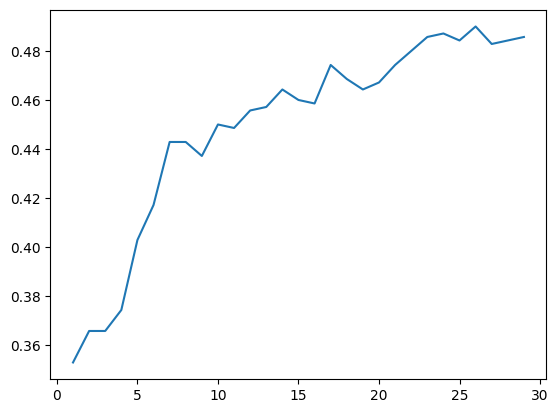

In [77]:
plt.plot(MIN_INFLUENCE_SUPPORT_V, prec_x_v)

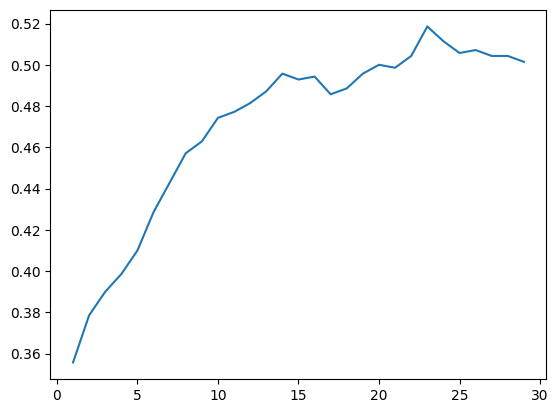

In [78]:
plt.plot(MIN_INFLUENCE_SUPPORT_V, prec_y_v)


In [75]:
prec_x_v[9], prec_y_v[9]

(np.float64(0.45), np.float64(0.45))

In [68]:
pd_stat_x_h1_v[-1]

,incoherent,not_influent,influence neg,influence pos,SUM
A nul,0,336,2,3,341
A neg,0,70,1,0,71
A pos,0,283,2,3,288
SUM,0,689,5,6,700


espèces totalement synthé allant dans le negatif

seulement le niveau 2 ?

PINN (neural networks)